# 03 — Embeddings y clustering — Exploit.in

Genera embeddings semánticos de los 5.289 posts clasificados con `qwen3-embedding` (4096 dims),  
aplica UMAP + HDBSCAN y visualiza la estructura semántica del foro.

Los centroides de actor son **L2-normalizados** y compatibles con el espacio vectorial  
de los módulos ContiLeaks, BlackBasta y LockBit → comparativa cruzada directa.

Produce:
- `data/processed/exploitin_message_embeddings.npy` — matriz (N, 4096)
- `data/processed/exploitin_sample_with_embeddings.parquet` — posts + coords UMAP + cluster

## 0. Setup

In [1]:
# "json" para leer el archivo de perfiles de usuarios generado en el notebook 02.
import json

# "numpy" (abreviado "np") es la librería fundamental para operaciones matemáticas
# con vectores y matrices en Python. Los embeddings son matrices de números flotantes
# y numpy es la herramienta ideal para trabajar con ellos.
import numpy as np

# "pandas" para trabajar con tablas de datos (DataFrames).
import pandas as pd

# "matplotlib.pyplot" para crear gráficas de dispersión y mapas de calor.
import matplotlib.pyplot as plt

# "matplotlib.cm" contiene paletas de colores predefinidas ("color maps").
# La usamos para asignar colores distintos a cada categoría en el scatter plot.
import matplotlib.cm as cm

# "ollama" para solicitar los embeddings al modelo local qwen3-embedding.
import ollama

# "umap" implementa el algoritmo UMAP (Uniform Manifold Approximation and Projection).
# UMAP es una técnica de reducción de dimensionalidad: toma vectores de 4096 dimensiones
# y los comprime a 2D para poder visualizarlos en una gráfica.
# Es similar a PCA pero mucho mejor para preservar la estructura local de los datos.
import umap

# "hdbscan" implementa el algoritmo HDBSCAN (Hierarchical Density-Based Spatial Clustering).
# Es un algoritmo de clustering que agrupa puntos cercanos en el espacio 2D sin necesidad
# de especificar el número de clusters de antemano. Los puntos que no encajan en ningún
# grupo se marcan como "ruido" (cluster -1).
import hdbscan

# "pathlib.Path" para manejar rutas de archivos.
from pathlib import Path

# "cosine_similarity" calcula la similitud coseno entre vectores.
# La similitud coseno mide el ángulo entre dos vectores: 1.0 = idénticos, 0.0 = perpendiculares.
# Es la métrica estándar para comparar embeddings semánticos.
from sklearn.metrics.pairwise import cosine_similarity

# "tqdm" para mostrar barras de progreso durante la generación de embeddings.
from tqdm.auto import tqdm

# Definimos las rutas de los archivos de entrada y salida.
PROCESSED      = Path('data/processed')
SAMPLE_IN      = PROCESSED / 'exploitin_sample_classified.parquet'    # posts clasificados (entrada)
PROFILES_IN    = PROCESSED / 'exploitin_user_profiles.json'           # perfiles LLM (entrada)
EMBEDDINGS_NPY = PROCESSED / 'exploitin_message_embeddings.npy'       # matriz de embeddings (salida)
SAMPLE_OUT     = PROCESSED / 'exploitin_sample_with_embeddings.parquet' # posts + coords UMAP (salida)

# Modelo de embeddings: qwen3-embedding genera vectores de 4096 dimensiones.
# Más dimensiones = representación semántica más rica, pero también más memoria y tiempo.
EMBED_MODEL = 'qwen3-embedding'
EMBED_DIMS  = 4096

# Tamaño del lote para enviar textos al modelo de embeddings.
# Enviamos 16 textos a la vez en lugar de uno por uno para mayor eficiencia.
# Es menor que en otros módulos porque con 4096 dimensiones la memoria se agota más rápido.
BATCH_SIZE  = 16

# Verificamos que los archivos de entrada existen antes de continuar.
assert SAMPLE_IN.exists(),   f'Falta {SAMPLE_IN} — ejecuta notebook 02'
assert PROFILES_IN.exists(), f'Falta {PROFILES_IN} — ejecuta notebook 02'

# Cargamos los posts clasificados y los perfiles de usuarios.
sample = pd.read_parquet(SAMPLE_IN).reset_index(drop=True)
with open(PROFILES_IN, encoding='utf-8') as f:
    profiles = json.load(f)

print(f'Posts    : {len(sample):,}')
print(f'Actores  : {sample.username.nunique():,}')
print(f'Perfiles : {len(profiles)}')
print(f'Modelo   : {EMBED_MODEL}  ({EMBED_DIMS}D)')
print(f'\nCategorías:\n{sample.category.value_counts().to_string()}')

/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Posts    : 5,289
Actores  : 1,081
Perfiles : 156
Modelo   : qwen3-embedding  (4096D)

Categorías:
category
community      1568
hacking         784
marketplace     775
programming     694
malware         658
spam            404
carding         291
unknown         115


## 1. Generación de embeddings

In [2]:
# Comprobamos si ya existe el archivo de embeddings guardado de una ejecución anterior.
# Generar embeddings para 5.289 posts tarda varios minutos, así que si ya están calculados
# los cargamos directamente desde disco en lugar de volver a calcularlos.
if EMBEDDINGS_NPY.exists():
    # "np.load()" carga una matriz numpy desde un archivo .npy (formato binario eficiente).
    embeddings = np.load(EMBEDDINGS_NPY)

    # Verificamos que el número de filas de la matriz coincide con el número de posts.
    # Si no coinciden, el archivo está corrupto o desactualizado.
    assert len(embeddings) == len(sample), 'Embeddings y muestra desalineados — borra el .npy y re-ejecuta'
    print(f'Cargados desde caché: {embeddings.shape}')
else:
    # Si no existe el archivo, generamos los embeddings desde cero.
    texts = sample['content'].str.strip().tolist()

    # Inicializamos una matriz de ceros con las dimensiones correctas.
    # dtype=np.float32 usa 4 bytes por número en lugar de 8 (float64), ahorrando memoria.
    # La matriz tendrá tantas filas como posts y 4096 columnas (una por dimensión del embedding).
    embeddings = np.zeros((len(texts), EMBED_DIMS), dtype=np.float32)

    # Procesamos los textos en lotes (batches) de BATCH_SIZE textos a la vez.
    # "range(0, len(texts), BATCH_SIZE)" genera los índices de inicio de cada lote:
    # 0, 16, 32, 48, ... hasta el final.
    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc='Embeddings'):
        # Extraemos el lote actual de textos y los truncamos a 800 caracteres.
        batch = [str(t)[:800] for t in texts[start:start + BATCH_SIZE]]

        # Solicitamos los embeddings a ollama. "resp.embeddings" es una lista de vectores.
        resp  = ollama.embed(model=EMBED_MODEL, input=batch)

        # Guardamos cada vector en la fila correspondiente de la matriz.
        for j, emb in enumerate(resp.embeddings):
            embeddings[start + j] = emb

    # Guardamos la matriz completa en un archivo .npy para no tener que recalcularla.
    np.save(EMBEDDINGS_NPY, embeddings)
    print(f'Embeddings guardados: {embeddings.shape}  → {EMBEDDINGS_NPY}')

print(f'Dimensiones: {embeddings.shape[1]}D')

Embeddings:   0%|          | 0/331 [00:00<?, ?it/s]

Embeddings:   0%|          | 1/331 [00:02<11:42,  2.13s/it]

Embeddings:   1%|          | 2/331 [00:02<06:55,  1.26s/it]

Embeddings:   1%|          | 3/331 [00:03<06:24,  1.17s/it]

Embeddings:   1%|          | 4/331 [00:04<05:42,  1.05s/it]

...

Embeddings:  99%|█████████▉| 329/331 [04:15<00:01,  1.19it/s]

Embeddings: 100%|█████████▉| 330/331 [04:16<00:00,  1.21it/s]

Embeddings: 100%|██████████| 331/331 [04:16<00:00,  1.39it/s]

Embeddings: 100%|██████████| 331/331 [04:16<00:00,  1.29it/s]

Embeddings guardados: (5289, 4096)  → data/processed/exploitin_message_embeddings.npy
Dimensiones: 4096D


## 2. Centroides por actor

Media L2-normalizada de todos los embeddings de cada usuario.  
Solo actores con ≥ 8 posts para centroides robustos.

In [3]:
# Calculamos el "centroide" de cada actor: un único vector que representa
# el "promedio semántico" de todos sus posts.
# 
# ¿Por qué centralizar? En lugar de comparar 156 actores × 5.289 posts (miles de comparaciones),
# con los centroides comparamos directamente actor vs. actor con un solo vector por persona.
# Esto también permite comparar actores de diferentes foros entre sí (ContiLeaks, LockBit, etc.)
# siempre que usen el mismo modelo de embeddings.
#
# ¿Por qué normalizar (L2)? La normalización L2 divide el vector por su longitud, lo que
# hace que todos los vectores tengan longitud 1. Con vectores normalizados, la similitud
# coseno es equivalente al producto punto (más rápido de calcular), y las comparaciones
# entre actores con distinto número de posts son más justas.

MIN_POSTS = 8  # mínimo de posts para calcular un centroide fiable

# Añadimos una columna con el índice de fila para poder localizar los embeddings
# correspondientes a cada post de cada usuario.
sample_indexed = sample.copy()
sample_indexed['emb_idx'] = range(len(sample_indexed))

# Diccionario donde guardaremos los centroides: {nombre_usuario: vector_4096d}
actor_centroids = {}

# Iteramos sobre los usuarios y calculamos el centroide de cada uno.
for actor, group in sample_indexed.groupby('username'):
    # Solo procesamos usuarios con suficientes posts.
    if len(group) < MIN_POSTS:
        continue

    # Obtenemos las filas de la matriz de embeddings correspondientes a este usuario.
    # "group['emb_idx'].tolist()" nos da los índices de fila de este usuario.
    vecs = embeddings[group['emb_idx'].tolist()]

    # Calculamos la media de todos los vectores del usuario (una suma / número de posts).
    c = vecs.mean(axis=0)

    # Normalizamos el vector dividiéndolo por su norma L2 (su "longitud" en el espacio).
    # "np.linalg.norm(c)" calcula la norma euclidiana del vector.
    c /= np.linalg.norm(c)

    # Guardamos el centroide normalizado.
    actor_centroids[actor] = c

# Creamos una lista ordenada de nombres y una matriz con todos los centroides.
actor_names  = list(actor_centroids.keys())

# "np.array([...])" convierte la lista de vectores en una matriz 2D de numpy.
# Cada fila es el centroide de un actor; la dimensión es (n_actores, 4096).
actor_matrix = np.array([actor_centroids[a] for a in actor_names])

print(f'Actores con centroide (≥{MIN_POSTS} posts): {len(actor_names)}')
print(f'Matriz de centroides: {actor_matrix.shape}')

Actores con centroide (≥8 posts): 156
Matriz de centroides: (156, 4096)


## 3. UMAP — reducción a 2D

In [4]:
# UMAP: reducción de dimensionalidad de 4096D → 2D para visualización.
#
# Los embeddings viven en un espacio de 4096 dimensiones que no podemos visualizar.
# UMAP proyecta esos vectores a 2 dimensiones intentando preservar las "vecindades":
# posts semánticamente similares quedan cerca en el mapa 2D, y posts distintos quedan lejos.
#
# Parámetros importantes:
# - n_components=2: proyectamos a 2 dimensiones (para poder graficar en X, Y).
# - n_neighbors=20: cuántos vecinos cercanos considera UMAP para cada punto.
#   Valores bajos → más estructura local; valores altos → más estructura global.
# - min_dist=0.1: distancia mínima entre puntos en el espacio 2D.
#   Valores bajos → puntos más agrupados; valores altos → más dispersión.
# - metric='cosine': usamos similitud coseno para medir distancias entre embeddings.
#   Es la métrica natural para embeddings de texto.
# - random_state=42: semilla para reproducibilidad (UMAP tiene un componente aleatorio).
print('Ajustando UMAP sobre posts...')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

# ".fit_transform()" ajusta el modelo UMAP sobre los embeddings de posts
# y devuelve las coordenadas 2D de cada post.
# Esta operación puede tardar varios minutos con 5.289 posts de 4096 dimensiones.
msg_2d   = reducer.fit_transform(embeddings)

# ".transform()" aplica el mismo espacio UMAP ya aprendido a los centroides de actores.
# Así los actores quedan en el mismo mapa que sus posts, lo que facilita la comparación visual.
actor_2d = reducer.transform(actor_matrix)

# Guardamos las coordenadas UMAP como nuevas columnas del DataFrame de posts.
# Esto nos permite colorear cada punto según su categoría o sección de foro más adelante.
sample['umap_x'] = msg_2d[:, 0]  # coordenada X (primer componente UMAP)
sample['umap_y'] = msg_2d[:, 1]  # coordenada Y (segundo componente UMAP)

print(f'Posts en 2D  : {msg_2d.shape}')
print(f'Actores en 2D: {actor_2d.shape}')

/home/drjekyll/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Ajustando UMAP sobre posts...


Posts en 2D  : (5289, 2)
Actores en 2D: (156, 2)


## 4. HDBSCAN — clustering

In [5]:
# HDBSCAN: clustering de posts en el espacio 2D generado por UMAP.
#
# HDBSCAN encuentra grupos ("clusters") de puntos que están densamente agrupados
# sin necesitar que le digamos de antemano cuántos clusters queremos.
# Es ideal para datos con forma irregular como los mapas UMAP.
#
# Parámetros para el clustering de POSTS:
# - min_cluster_size=40: un cluster debe tener al menos 40 posts para ser válido.
#   Clusters más pequeños se consideran "ruido" (cluster -1).
# - min_samples=5: un punto debe tener al menos 5 vecinos cercanos para ser "central".
clusterer_posts = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=5)

# ".fit_predict()" ajusta el modelo y devuelve el ID de cluster para cada post.
# -1 significa que ese post no pertenece a ningún cluster (es "ruido" o un punto aislado).
post_clusters = clusterer_posts.fit_predict(msg_2d)

# Añadimos el ID de cluster como columna del DataFrame de posts.
sample['cluster'] = post_clusters

# Contamos cuántos clusters se formaron (excluyendo el cluster -1 que es ruido).
n_clusters = (np.unique(post_clusters) >= 0).sum()
print(f'Clusters de posts   : {n_clusters}')
print(f'Ruido (cluster -1)  : {(post_clusters == -1).sum():,} posts')

# Clustering de los ACTORES (centroides en 2D).
# Usamos parámetros más permisivos porque hay menos actores (156) que posts (5.289).
# - min_cluster_size=3: basta con 3 actores para formar un cluster.
# - min_samples=2: un actor necesita solo 2 vecinos para ser considerado "central".
# - metric='euclidean': aquí usamos distancia euclídea porque los puntos 2D de UMAP
#   ya están en un espacio donde la distancia directa tiene sentido geométrico.
clusterer_actors = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=2, metric='euclidean')
actor_clusters = clusterer_actors.fit_predict(actor_2d)

# Contamos los clusters de actores.
n_actor_cl = len(set(actor_clusters)) - (1 if -1 in actor_clusters else 0)
n_noise_ac = (actor_clusters == -1).sum()
print(f'\nClusters de actores : {n_actor_cl}')
print(f'Actores sin cluster : {n_noise_ac}')
print()

# Mostramos qué actores quedaron en cada cluster para inspección manual.
for cl in sorted(set(actor_clusters)):
    members = [actor_names[i] for i, c in enumerate(actor_clusters) if c == cl]
    label = 'ruido' if cl == -1 else f'cluster {cl}'
    # Mostramos solo los primeros 8 actores de cada cluster para no saturar la salida.
    print(f'  {label:<12}: {members[:8]}{" ..." if len(members)>8 else ""}')

Clusters de posts   : 32
Ruido (cluster -1)  : 1,779 posts

Clusters de actores : 12
Actores sin cluster : 28

  ruido       : ['Exper1menT', 'Hytex', 'Imper1um', 'Kallisto', 'Ni0x', 'Nilson', 'Noctambulaar', 'Nucleus'] ...
  cluster 0   : ['3l33t', 'CkaZu', 'Ego1st', 'Marduk', 'Robin Gud', 'Stalin', 'hellwood', 'hsi']
  cluster 1   : ['Obivankor', 'Richy', 'Transporter', 'debug', 'deric', 'krot', 'parik', 'starw']
  cluster 2   : ['Deret', 'L0ki', 'eraflame']
  cluster 3   : ['Admin CI', 'Azazel', 'GOoDok', 'smilesxxx', 'takahashi']
  cluster 4   : ['()G3R', 'Romisnet', 'Sta&#33;&#036;', 'Toredo', '_Master-', 'sclan']
  cluster 5   : ['Ar3s', 'Ghost Bear', 'ultra']
  cluster 6   : ['D15', 'DeaDMonaX', 'DeadStudent', 'Trash', 'pahomoff', 'slavarion']
  cluster 7   : ['Caponex', 'rrr111', 'vesselii', 'zybc']
  cluster 8   : ['Out', 'Plaza', 'plague', 'мани']
  cluster 9   : ['Djeike 2.0', 'JFK', 'OniX', 'USD', 'Varchun', 'bu&#33;ik', 'lift', 'm4rrow'] ...
  cluster 10  : ['Mаil2k', 'mad

## 5. Visualizaciones

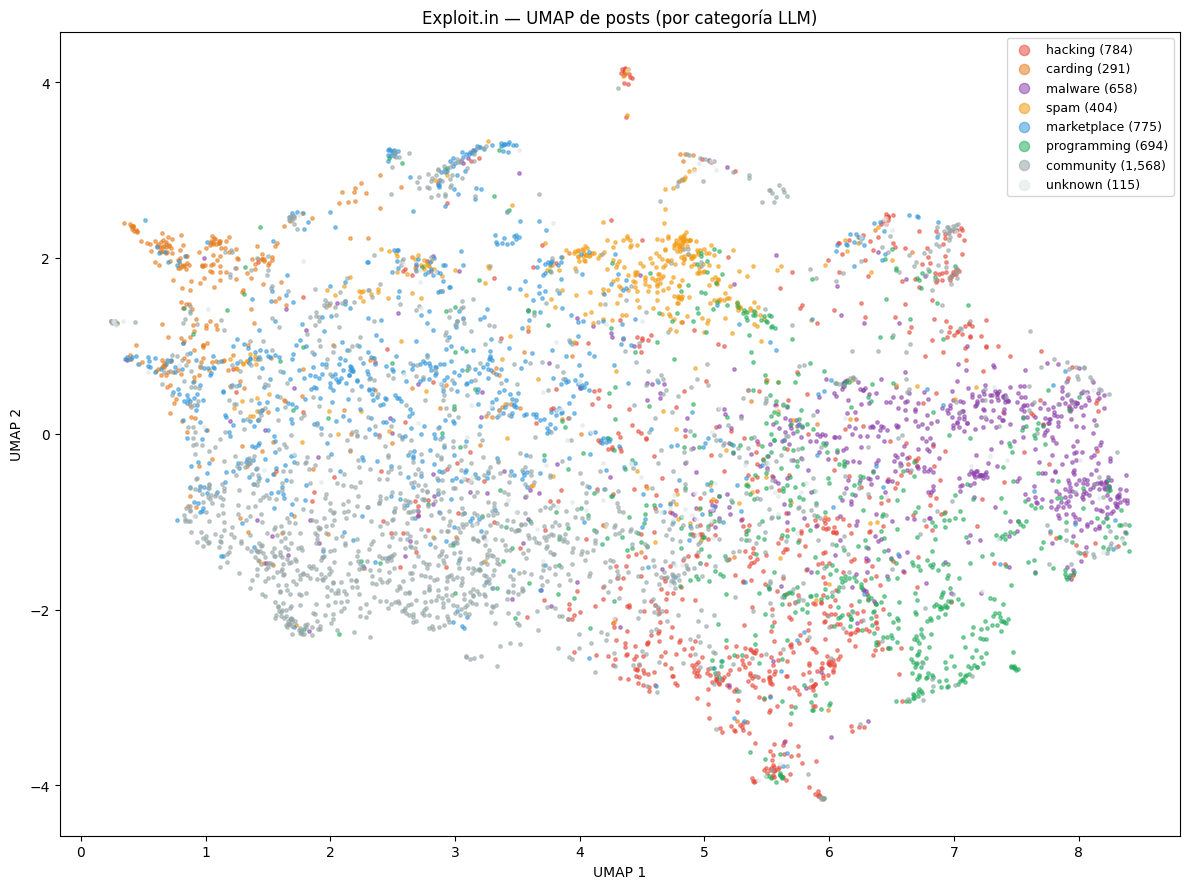

In [6]:
# Paleta de colores por categoría LLM (la misma que usamos en el notebook 02).
cat_colors = {
    'hacking':     '#e74c3c',
    'carding':     '#e67e22',
    'malware':     '#8e44ad',
    'spam':        '#f39c12',
    'marketplace': '#3498db',
    'programming': '#27ae60',
    'community':   '#95a5a6',
    'unknown':     '#dfe6e9',
}

# Creamos el scatter plot UMAP coloreado por categoría LLM.
# Cada punto representa un post; su posición refleja su similitud semántica con los demás.
# Posts semánticamente similares aparecen agrupados en el mapa.
fig, ax = plt.subplots(figsize=(12, 9))

# Dibujamos cada categoría por separado para poder añadir su entrada en la leyenda.
for cat, color in cat_colors.items():
    # Creamos una máscara booleana para seleccionar solo los posts de esta categoría.
    mask = sample['category'] == cat
    if mask.sum() == 0:
        continue

    # "scatter" dibuja puntos individuales en el gráfico.
    # - msg_2d[mask, 0]: coordenadas X de los posts de esta categoría
    # - msg_2d[mask, 1]: coordenadas Y de los posts de esta categoría
    # - s=6: tamaño del punto (pequeño porque hay muchos)
    # - alpha=0.55: semitransparente para ver la densidad de puntos superpuestos
    # - rasterized=True: convierte los puntos a imagen (más eficiente con miles de puntos)
    ax.scatter(msg_2d[mask, 0], msg_2d[mask, 1],
               c=color, s=6, alpha=0.55, label=f'{cat} ({mask.sum():,})', rasterized=True)

ax.set_title('Exploit.in — UMAP de posts (por categoría LLM)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
# "markerscale=3" hace más grandes los marcadores en la leyenda para que sean más visibles.
ax.legend(markerscale=3, fontsize=9, loc='best')
plt.tight_layout()
plt.show()

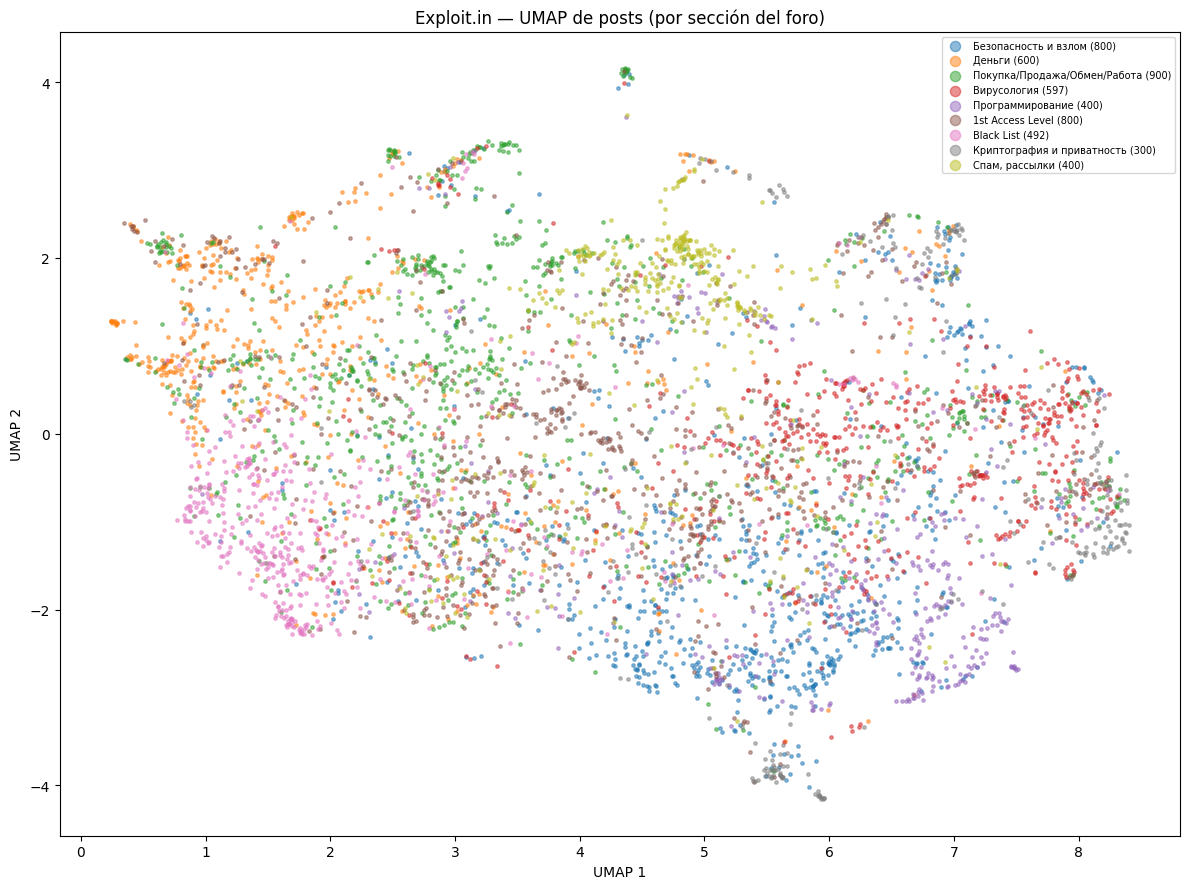

In [7]:
# Segundo scatter UMAP, esta vez coloreado por SECCIÓN del foro en lugar de por categoría LLM.
# Comparar este gráfico con el anterior permite ver si la estructura semántica
# refleja más la sección del foro o la categoría asignada por el LLM.
sections = sample['forum_name'].unique()

# Usamos "tab10", una paleta de 10 colores distintos pensada para datos categóricos.
# "%" (módulo) asegura que si hay más de 10 secciones, los colores se repitan cíclicamente.
palette  = cm.tab10.colors

fig, ax = plt.subplots(figsize=(12, 9))

for i, sec in enumerate(sections):
    mask = sample['forum_name'] == sec
    ax.scatter(msg_2d[mask, 0], msg_2d[mask, 1],
               # Cada sección recibe un color diferente de la paleta tab10.
               c=[palette[i % len(palette)]], s=6, alpha=0.5,
               # La leyenda muestra el nombre truncado de la sección y cuántos posts tiene.
               label=f'{sec[:30]} ({mask.sum():,})', rasterized=True)

ax.set_title('Exploit.in — UMAP de posts (por sección del foro)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=3, fontsize=7, loc='best')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2539543/4051518999.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],


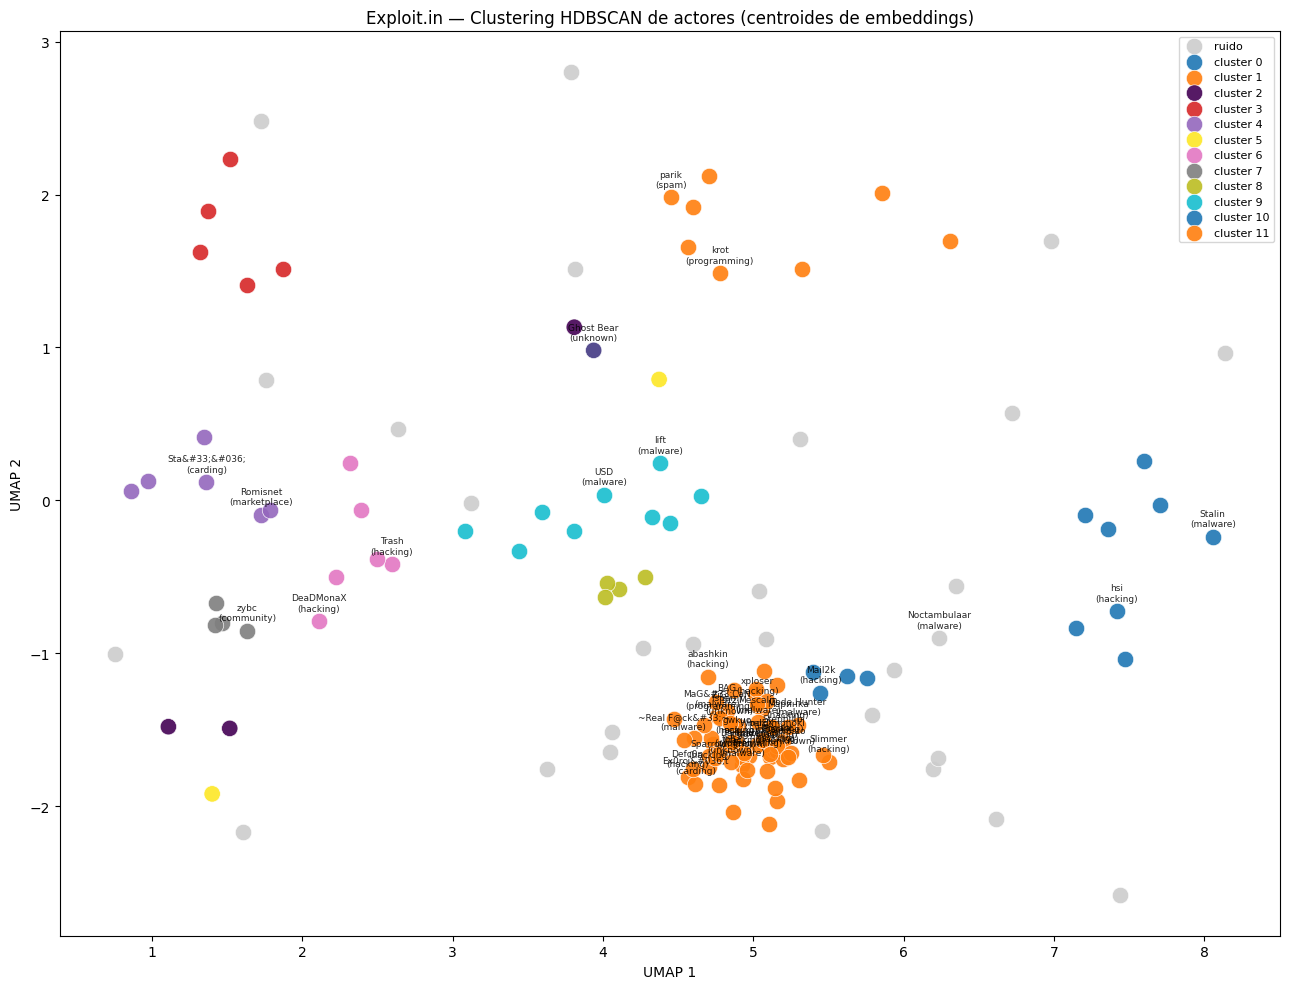

Cluster HDBSCAN × Especialidad LLM:
specialty  carding  community  hacking  malware  marketplace  programming  \
cluster                                                                     
-1               3          1        7        7            1            5   
 0               0          0        2        6            0            0   
 1               1          0        0        0            0            2   
 2               1          1        0        0            0            0   
 3               3          1        0        0            0            0   
 4               2          1        0        1            1            0   
 5               0          1        0        0            0            1   
 6               0          2        3        0            0            0   
 7               0          1        0        0            1            0   
 8               1          1        0        2            0            0   
 9               1          1        4  

In [8]:
# Tercer scatter: posicionamiento de los ACTORES en el espacio UMAP,
# coloreados por su cluster HDBSCAN. Cada actor es un punto más grande que los posts.
fig, ax = plt.subplots(figsize=(13, 10))

for cl in sorted(set(actor_clusters)):
    # Máscara para los actores de este cluster.
    mask  = actor_clusters == cl

    # Los actores sin cluster (ruido, cl == -1) se muestran en gris.
    color = '#cccccc' if cl == -1 else palette[cl % len(palette)]
    label = 'ruido' if cl == -1 else f'cluster {cl}'

    # Dibujamos los actores como puntos más grandes (s=140) con borde blanco para destacarlos.
    ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],
               c=color, s=140, alpha=0.9, label=label,
               edgecolors='white', linewidths=0.5, zorder=3)

# Identificamos los 40 actores con más posts en la muestra para etiquetarlos.
# Solo etiquetamos los más activos para no saturar el gráfico de texto.
top_actors = sample.groupby('username').size().nlargest(40).index

# Añadimos anotaciones de texto encima de cada actor importante.
for i, name in enumerate(actor_names):
    if name in top_actors:
        # Obtenemos la especialidad del actor desde los perfiles LLM.
        role = profiles.get(name, {}).get('specialty', '?')
        # "ax.annotate()" añade texto anclado a una posición del gráfico.
        # "xytext=(0, 6)" desplaza el texto 6 píxeles hacia arriba del punto.
        ax.annotate(f'{name}\n({role})', (actor_2d[i, 0], actor_2d[i, 1]),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 6), textcoords='offset points', alpha=0.85)

ax.set_title('Exploit.in — Clustering HDBSCAN de actores (centroides de embeddings)')
ax.legend(fontsize=8)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

# Creamos un DataFrame con la información completa de cada actor
# para facilitar análisis posteriores y exportación.
actor_df = pd.DataFrame({
    'actor':      actor_names,
    'cluster':    actor_clusters,        # cluster HDBSCAN asignado
    'umap_x':     actor_2d[:, 0],        # coordenada X en el mapa UMAP
    'umap_y':     actor_2d[:, 1],        # coordenada Y en el mapa UMAP
    # Obtenemos la especialidad y rol de los perfiles LLM usando .get() por si algún actor
    # no tiene perfil (usamos '?' como valor por defecto en ese caso).
    'specialty':  [profiles.get(a, {}).get('specialty', '?') for a in actor_names],
    'role':       [profiles.get(a, {}).get('role', '?') for a in actor_names],
    'confidence': [profiles.get(a, {}).get('confidence', 'low') for a in actor_names],
})

# Tabla cruzada que compara el cluster HDBSCAN con la especialidad LLM.
# Esto permite ver si los clusters geométricos coinciden con las categorías del LLM.
print('Cluster HDBSCAN × Especialidad LLM:')
print(pd.crosstab(actor_df['cluster'], actor_df['specialty']))

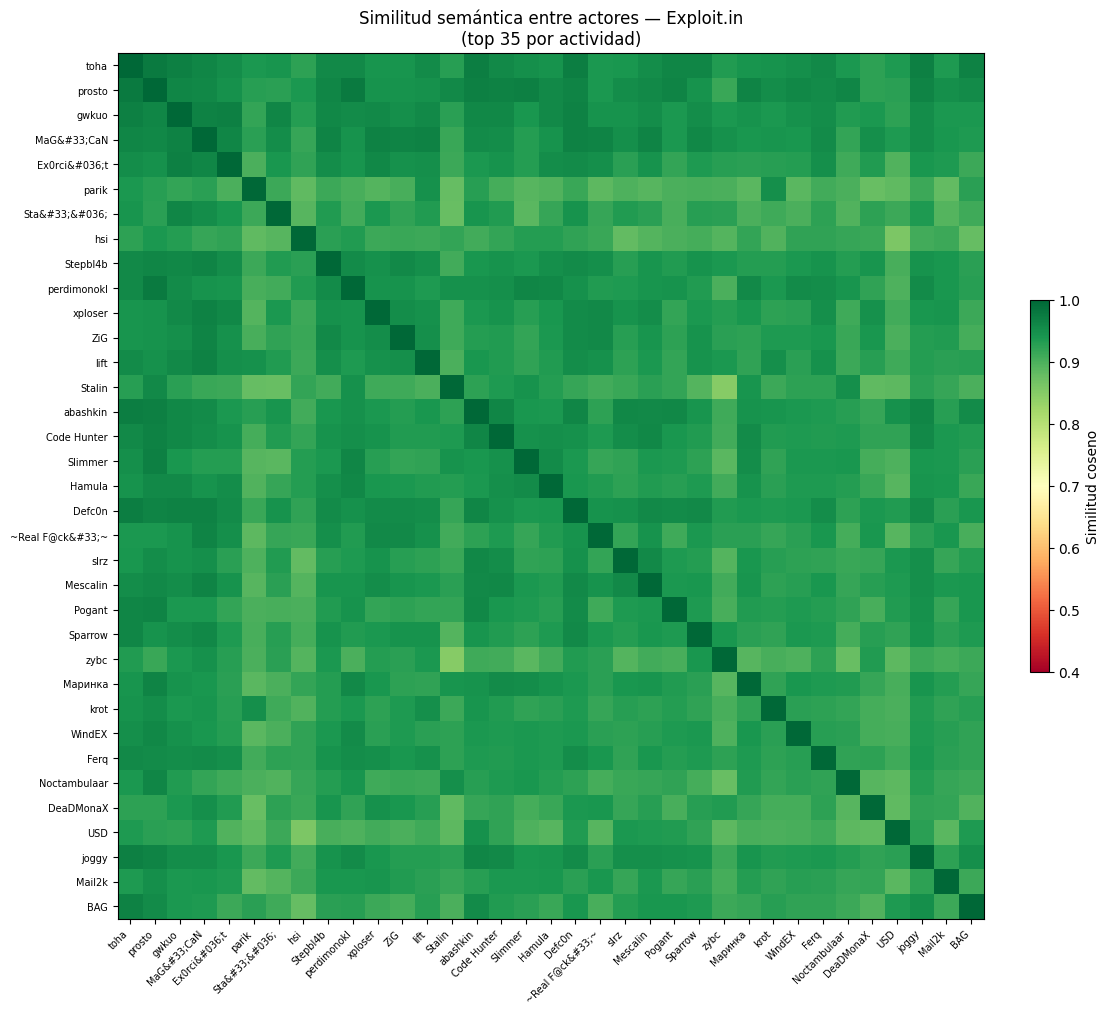

Top 5 pares con mayor similitud semántica:
  toha                [unknown     ] ↔ prosto              [unknown     ]  sim=0.976
  prosto              [unknown     ] ↔ perdimonokl         [hacking     ]  sim=0.974
  toha                [unknown     ] ↔ Defc0n              [hacking     ]  sim=0.971
  toha                [unknown     ] ↔ abashkin            [hacking     ]  sim=0.970
  prosto              [unknown     ] ↔ Slimmer             [hacking     ]  sim=0.969


In [9]:
# Calculamos la similitud coseno entre los centroides de los 35 actores más activos.
# Esto produce un "mapa de calor" que muestra quién es semánticamente similar a quién.
# Una similitud alta (→ 1.0) indica que dos actores escriben sobre temas parecidos.

# Seleccionamos los 35 actores con más posts en la muestra.
# ".nlargest(35)" devuelve los 35 mayores valores con sus índices (nombres de actores).
top35 = sample.groupby('username').size().nlargest(35).index.tolist()

# Filtramos a los que tienen centroide calculado (algunos podrían no tenerlo
# si tienen menos de MIN_POSTS posts, aunque esto no debería ocurrir con los top35).
top35 = [a for a in top35 if a in actor_centroids]

# Creamos la submatriz de centroides para estos 35 actores.
mat35 = np.array([actor_centroids[a] for a in top35])

# "cosine_similarity()" calcula todas las similitudes pairwise de una sola vez.
# El resultado es una matriz cuadrada (35×35) donde sim35[i,j] = similitud entre actor i y actor j.
# La diagonal es 1.0 (cada actor es 100% similar a sí mismo).
sim35 = cosine_similarity(mat35)

# Calculamos el tamaño de la figura de forma dinámica para que se vea bien
# independientemente del número de actores.
n = len(top35)
fig_sz = max(9, n * 0.32)
fig, ax = plt.subplots(figsize=(fig_sz, fig_sz))

# Mostramos el heatmap con la escala de colores 'RdYlGn':
# - Verde: similitud alta (actores que escriben sobre lo mismo)
# - Amarillo: similitud media
# - Rojo: similitud baja (actores con temáticas distintas)
# "vmin=0.4, vmax=1.0" fija la escala: 0.4 es el rango interesante de variación para embeddings.
im = ax.imshow(sim35, cmap='RdYlGn', vmin=0.4, vmax=1.0)

# Configuramos las etiquetas de los ejes con los nombres de los actores.
ax.set_xticks(range(n))
ax.set_xticklabels(top35, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(n))
ax.set_yticklabels(top35, fontsize=7)

plt.colorbar(im, ax=ax, fraction=0.02, label='Similitud coseno')
ax.set_title('Similitud semántica entre actores — Exploit.in\n(top 35 por actividad)')
plt.tight_layout()
plt.show()

# Buscamos los pares de actores con mayor similitud (los "más parecidos").
# Primero ponemos la diagonal a -1 para que no aparezca un actor consigo mismo.
np.fill_diagonal(sim35, -1)

# Generamos todos los pares únicos (sin repetir i,j y j,i) y los ordenamos por similitud.
pairs = []
for i in range(n):
    for j in range(i+1, n):  # "i+1" evita duplicados y la diagonal
        pairs.append((sim35[i,j], top35[i], top35[j]))
pairs.sort(reverse=True)  # ordenamos de mayor a menor similitud

# Mostramos los 5 pares más similares con sus especialidades LLM para interpretar el resultado.
print('Top 5 pares con mayor similitud semántica:')
for sim, a, b in pairs[:5]:
    ra = profiles.get(a, {}).get('specialty', '?')
    rb = profiles.get(b, {}).get('specialty', '?')
    print(f'  {a:20s}[{ra:12s}] ↔ {b:20s}[{rb:12s}]  sim={sim:.3f}')

## 6. Guardar

In [10]:
# Guardamos el DataFrame de posts enriquecido con las coordenadas UMAP y el cluster.
# Este archivo será la entrada para el notebook de comparativa cruzada entre foros
# (ContiLeaks, BlackBasta, LockBit y Exploit.in en el mismo espacio vectorial).
sample.to_parquet(SAMPLE_OUT, index=False)

# Resumen final de todos los archivos generados por este notebook.
print(f'Embeddings      → {EMBEDDINGS_NPY}  {embeddings.shape}')
print(f'Posts + UMAP    → {SAMPLE_OUT}')
print(f'\nResumen:')
print(f'  Posts embebidos    : {len(sample):,}')
print(f'  Dimensiones        : {embeddings.shape[1]}D  ({EMBED_MODEL})')
print(f'  Clusters de posts  : {n_clusters}')
print(f'  Actores analizados : {len(actor_names)}')
print(f'  Clusters de actores: {n_actor_cl}')
print()
# Listamos los tres archivos que se usarán en el análisis comparativo multi-foro.
print('Archivos listos para el notebook comparativo:')
print(f'  exploitin_message_embeddings.npy')       # matriz (5289, 4096) de embeddings
print(f'  exploitin_sample_with_embeddings.parquet') # posts + UMAP + cluster
print(f'  exploitin_user_profiles.json')            # perfiles LLM de 156 actores

Embeddings      → data/processed/exploitin_message_embeddings.npy  (5289, 4096)
Posts + UMAP    → data/processed/exploitin_sample_with_embeddings.parquet

Resumen:
  Posts embebidos    : 5,289
  Dimensiones        : 4096D  (qwen3-embedding)
  Clusters de posts  : 32
  Actores analizados : 156
  Clusters de actores: 12

Archivos listos para el notebook comparativo:
  exploitin_message_embeddings.npy
  exploitin_sample_with_embeddings.parquet
  exploitin_user_profiles.json
